**Ingestion**

In [0]:
path = "/Volumes/rg_azure_databricks/default/filestore"
customers_df = spark.read.option("header",True).option("inferSchema",True).csv(f"{path}/customers.csv")

display(customers_df)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


In [0]:
products_df = spark.read.option("header",True).option("inferSchema",True).csv(f"{path}/products.csv")

display(products_df)

product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


In [0]:
orders_df = spark.read.option("header",True).option("inferSchema",True).csv(f"{path}/orders.csv")

display(orders_df)

order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


In [0]:
preferences_df = spark.read.option("multiline",True).json(f"{path}/customer_preferences.json")

display(preferences_df)

customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


In [0]:
customers_df.printSchema()
products_df.printSchema()
orders_df.printSchema()
preferences_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
customers_df.write.format("delta").mode("overwrite").saveAsTable("bronze_customers") 
products_df.write.format("delta").mode("overwrite").saveAsTable("bronze_products") 
orders_df.write.format("delta").mode("overwrite").saveAsTable("bronze_orders") 
preferences_df.write.format("delta").mode("overwrite").saveAsTable("bronze_customer_preferences")

**Cleaning and Transformation**

In [0]:
from pyspark.sql.functions import col

customers_df = customers_df.na.fill({
    "customer_name":"Unknown",
    "city":"Unknown",
    "state":"Unknown",
    "customer_type":"Regular"
})

products_df = products_df.na.fill({
    "product_name":"Unknown",
    "category":"Unknown",
    "unit_price":0
})

orders_df = orders_df.na.fill({
    "quantity":0,
    "status":"Pending"
})


In [0]:
pref_flat_df = preferences_df.select(
    col("customer_id"),
    col("preferred_channel"),
    col("loyalty.tier").alias("tier"),
    col("loyalty.points").alias("points")
)

display(pref_flat_df)

customer_id,preferred_channel,tier,points
C101,Online,Gold,1200
C102,Store,Silver,700
C104,Online,Platinum,2200
C108,Mobile App,Gold,1500


In [0]:
customer_pref = customers_df.join(
    pref_flat_df,
    on="customer_id",
    how="left"
)

display(customer_pref)

customer_id,customer_name,city,state,customer_type,preferred_channel,tier,points
C101,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


In [0]:
orders_customers = orders_df.join(
    customer_pref,
    on="customer_id",
    how="inner"
)

display(orders_customers)

customer_id,order_id,product_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points
C101,O1009,P102,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C101,O1001,P101,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,O1002,P102,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,O1003,P103,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,O1010,P101,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C104,O1004,P104,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,O1005,P105,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,O1006,P106,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,O1007,P107,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,O1008,P108,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


In [0]:
retail_df= orders_customers.join(
    products_df,
    on="product_id",
    how="inner"
)

display(retail_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000


In [0]:
retail_df = retail_df.withColumn(
    "revenue",
    col("quantity") * col("unit_price")
)

display(retail_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price,revenue
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000,21000
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500,18000
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000


In [0]:
from pyspark.sql.functions import month  
 
retail_df= retail_df.withColumn(
    "order_month",
    month("order_date")
)

display(retail_df.select("order_date", "order_month"))

order_date,order_month
2026-06-05,6
2026-06-01,6
2026-06-01,6
2026-06-02,6
2026-06-05,6
2026-06-02,6
2026-06-03,6
2026-06-03,6
2026-06-04,6
2026-06-04,6


In [0]:
from pyspark.sql.functions import when

retail_df = retail_df.withColumn(
    "customer_segment",
    when(col("customer_type")=="Premium","High Value"
    ).otherwise("Standard Value")
)

display(retail_df.select("customer_id","customer_name","customer_segment"))

customer_id,customer_name,customer_segment
C101,Rahul Sharma,High Value
C101,Rahul Sharma,High Value
C102,Priya Reddy,Standard Value
C103,Amit Kumar,Standard Value
C104,Sneha Patel,High Value
C104,Sneha Patel,High Value
C105,Farhan Ali,Standard Value
C106,Neha Singh,High Value
C107,Arjun Verma,Standard Value
C108,Meera Nair,High Value


In [0]:
retail_df.write.format("delta").mode("overwrite").saveAsTable("silver_retail")

**Spark SQL**

In [0]:
retail_df.createOrReplaceTempView("retail_sales")

In [0]:
%sql
SELECT SUM(revenue) AS total_revenue
FROM retail_sales;

total_revenue
336000


In [0]:
%sql
SELECT city,SUM(revenue) AS revenue FROM retail_sales
GROUP BY city
ORDER BY revenue DESC;

city,revenue
Hyderabad,135000
Delhi,89000
Bangalore,50000
Mumbai,21000
Chennai,18000
Kochi,15000
Pune,8000


In [0]:
%sql
SELECT category, SUM(revenue) AS revenue FROM retail_sales
GROUP BY category
ORDER BY revenue DESC;

category,revenue
Electronics,250000
Furniture,45000
Fashion,41000


In [0]:
%sql
SELECT customer_name,SUM(revenue) AS revenue FROM retail_sales
GROUP BY customer_name
ORDER BY revenue DESC
LIMIT 5;

customer_name,revenue
Rahul Sharma,90000
Sneha Patel,89000
Priya Reddy,50000
Arjun Verma,45000
Amit Kumar,21000


In [0]:
%sql
SELECT * FROM retail_sales
WHERE status='Completed';

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price,revenue,order_month,customer_segment
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000,6,High Value
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000,6,Standard Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000,6,High Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000,6,High Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000,6,High Value


**Window Functions**

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

product_window = Window.orderBy(desc("total_revenue"))

product_rank = retail_df.groupBy(
    "product_name"
).agg(
    sum("revenue").alias("total_revenue")
).withColumn(
    "rank",
    rank().over(product_window)
)

display(product_rank)

product_name,total_revenue,rank
Laptop,130000,1
Mobile,75000,2
TV,45000,3
Table,24000,4
Chair,21000,5
Shoes,18000,6
Bag,15000,7
Watch,8000,8


In [0]:
customer_window = Window.orderBy(desc("total_revenue"))

customer_rank = retail_df.groupBy(
    "customer_name"
).agg(
    sum("revenue").alias("total_revenue")
).withColumn(
    "rank",
    rank().over(customer_window)
)

display(customer_rank)

customer_name,total_revenue,rank
Rahul Sharma,90000,1
Sneha Patel,89000,2
Priya Reddy,50000,3
Arjun Verma,45000,4
Amit Kumar,21000,5
Farhan Ali,18000,6
Meera Nair,15000,7
Neha Singh,8000,8


In [0]:
customer_rank.filter(col("rank") <= 3).show()

+-------------+-------------+----+
|customer_name|total_revenue|rank|
+-------------+-------------+----+
| Rahul Sharma|        90000|   1|
|  Sneha Patel|        89000|   2|
|  Priya Reddy|        50000|   3|
+-------------+-------------+----+



In [0]:
category_window = Window.partitionBy(
    "category"
).orderBy(desc("total_revenue"))

top_products = retail_df.groupBy(
    "category",
    "product_name"
).agg(
    sum("revenue").alias("total_revenue")
).withColumn(
    "rank",
    rank().over(category_window)
).filter("rank=1")

display(top_products)

category,product_name,total_revenue,rank
Electronics,Laptop,130000,1
Fashion,Shoes,18000,1
Furniture,Table,24000,1


In [0]:
running_window = Window.orderBy("order_date")

running_df = retail_df.groupBy(
    "order_date"
).agg(
    sum("revenue").alias("daily_revenue")
).withColumn(
    "running_revenue",
    sum("daily_revenue").over(running_window)
)

display(running_df)

order_date,daily_revenue,running_revenue
2026-06-01,115000,115000
2026-06-02,45000,160000
2026-06-03,26000,186000
2026-06-04,60000,246000
2026-06-05,90000,336000


**Delta Lake**

In [0]:
retail_df.write.format("delta").mode("overwrite").save("/mnt/delta/retail")

In [0]:
retail_df.write.format("delta").mode("overwrite").saveAsTable("retail_delta")

In [0]:
%sql
CREATE TABLE retail_sql
USING DELTA
AS
SELECT * FROM retail_sales;

num_affected_rows,num_inserted_rows


In [0]:
%sql
DESCRIBE HISTORY retail_delta;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T08:53:05Z,149040834249995,azuser7219_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> false)",null,List(454155129810502),null,0622-033954-ly4ykbq3,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 6895)",null,Databricks-Runtime/18.x-cpu-ml-scala2.13


In [0]:
%sql
SELECT * FROM healthcare_delta VERSION AS OF 0;

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,preferred_hospital,phone,email,doctor_name,department,doctor_city,consultation_fee,final_bill,appointment_month,patient_age_group
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Ramesh,Cardiology,Hyderabad,1500,6500,2026-06,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com,Dr. Priya,Neurology,Bangalore,2000,5500,2026-06,Young
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,null,Dr. Anita,Dermatology,Chennai,1000,3000,2026-06,Adult
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,14500,2026-06,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,null,Dr. Meera,Pediatrics,Delhi,1200,2700,2026-06,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,null,Dr. Kiran,Cardiology,Hyderabad,3000,10000,2026-06,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,null,Dr. Ramesh,Cardiology,Hyderabad,1500,7000,2026-06,Young
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com,Dr. Anita,Dermatology,Chennai,1000,3500,2026-06,Adult
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com,Dr. Kiran,Cardiology,Hyderabad,3000,9500,2026-06,Adult
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com,Dr. Suresh,Orthopedics,Mumbai,2500,7000,2026-06,Adult


In [0]:
from delta.tables import DeltaTable

updated_customer = spark.createDataFrame([
("C101","Rahul Sharma","Mumbai","Maharashtra","Premium")
],["customer_id","customer_name","city","state","customer_type"])

delta_table = DeltaTable.forName(
    spark,
    "bronze_customers"
)

delta_table.alias("t").merge(
    updated_customer.alias("s"),
    "t.customer_id=s.customer_id"
).whenMatchedUpdateAll() \
 .whenNotMatchedInsertAll() \
 .execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
%sql
DESCRIBE HISTORY bronze_customers;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-22T08:57:09Z,149040834249995,azuser7219_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(customer_id#24338 = customer_id#24328)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(454155129810502),null,0622-033954-ly4ykbq3,1,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 1928, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 1, executionTimeMs -> 4813, materializeSourceTimeMs -> 772, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 1403, numTargetRowsUpdated -> 1, numOutputRows -> 1, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 1, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 2612)",null,Databricks-Runtime/18.x-cpu-ml-scala2.13
1,2026-06-22T07:39:19Z,149040834249995,azuser7219_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> false)",null,List(454155129810502),null,0622-033954-ly4ykbq3,0,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 1, numRemovedBytes -> 2179, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 2179)",null,Databricks-Runtime/18.x-cpu-ml-scala2.13
0,2026-06-22T07:38:27Z,149040834249995,azuser7219_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> false)",null,List(454155129810502),null,0622-033954-ly4ykbq3,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 2179)",null,Databricks-Runtime/18.x-cpu-ml-scala2.13


In [0]:
%sql
OPTIMIZE retail_delta;

path,metrics
abfss://unity-catalog-storage@dbstorageoa7kihwyi26rk.dfs.core.windows.net/7405619834863317/__unitystorage/catalogs/87069ed1-8e5c-4c00-af7e-233acc1a57e9/tables/da1d043c-853c-436e-a515-189fdcbf59dc,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782118701145, 1782118702376, 4, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql
OPTIMIZE retail_delta
ZORDER BY (city);

path,metrics
abfss://unity-catalog-storage@dbstorageoa7kihwyi26rk.dfs.core.windows.net/7405619834863317/__unitystorage/catalogs/87069ed1-8e5c-4c00-af7e-233acc1a57e9/tables/da1d043c-853c-436e-a515-189fdcbf59dc,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 6895), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782118714602, 1782118715973, 4, 0, null, List(0, 0), null, 19, 19, 0, 0, null, null)"


In [0]:
%sql
VACUUM retail_delta RETAIN 168 HOURS;

path
abfss://unity-catalog-storage@dbstorageoa7kihwyi26rk.dfs.core.windows.net/7405619834863317/__unitystorage/catalogs/87069ed1-8e5c-4c00-af7e-233acc1a57e9/tables/da1d043c-853c-436e-a515-189fdcbf59dc


**Visualization**

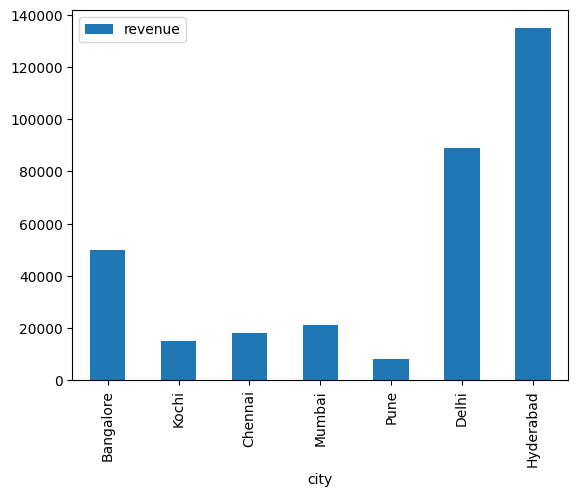

In [0]:
import matplotlib.pyplot as plt

city_df = retail_df.groupBy("city").agg(sum("revenue").alias("revenue")).toPandas()

city_df.plot(
    x="city",
    y="revenue",
    kind="bar"
)
plt.show()

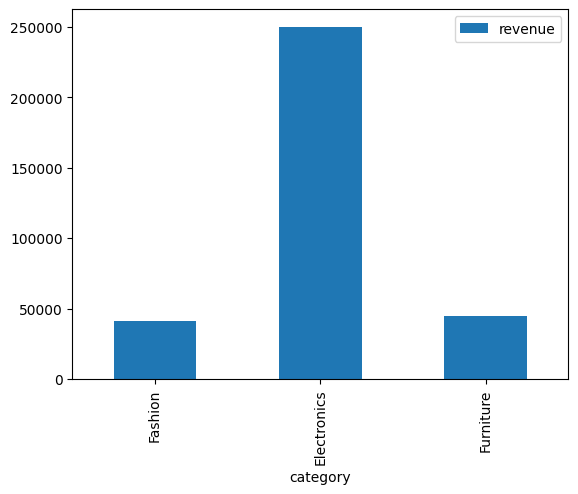

In [0]:
category_df = retail_df.groupBy("category").agg(sum("revenue").alias("revenue")).toPandas()

category_df.plot(
    x="category",
    y="revenue",
    kind="bar"
)
plt.show()

<Axes: ylabel='count'>

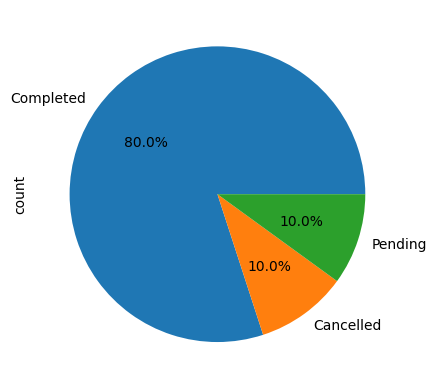

In [0]:
status_df = retail_df.groupBy("status").count().toPandas()

status_df.set_index("status")["count"].plot(kind="pie",autopct="%1.1f%%")

<Axes: ylabel='product_name'>

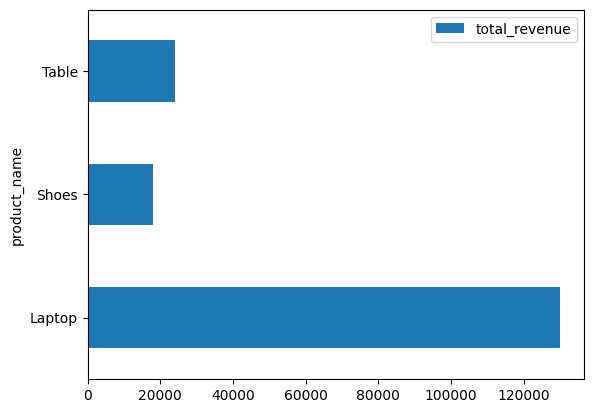

In [0]:
top_products.toPandas().plot(
    x="product_name",
    y="total_revenue",
    kind="barh"
)

<Axes: xlabel='order_date'>

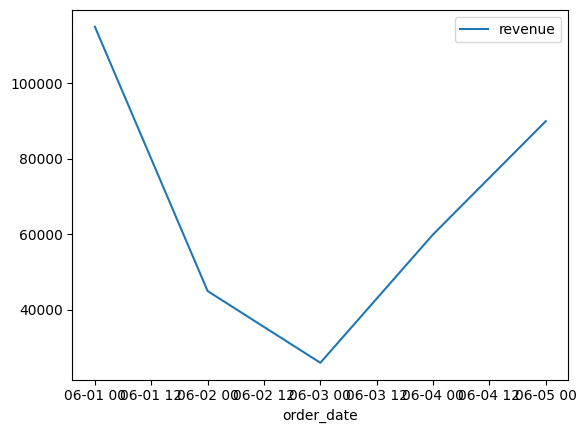

In [0]:
trend_df = retail_df.groupBy("order_date").agg(sum("revenue").alias("revenue")).orderBy("order_date").toPandas()

trend_df.plot(
    x="order_date",
    y="revenue",
    kind="line"
)

**Tables and Views**

In [0]:
%sql
CREATE TABLE managed_sales
USING DELTA
AS
SELECT * FROM retail_sales;

num_affected_rows,num_inserted_rows


In [0]:
%sql
CREATE TABLE external_sales
USING DELTA
LOCATION 'abfss://unity-catalog-storage@dbstorageoa7kihwyi26rk.dfs.core.windows.net/7405619834863317/external_sales';

In [0]:
%sql
CREATE OR REPLACE TEMP VIEW temp_sales
AS
SELECT * FROM retail_sales;

In [0]:
%sql
CREATE OR REPLACE GLOBAL TEMP VIEW global_sales
AS
SELECT * FROM retail_sales;

In [0]:
df = spark.createDataFrame(
    [
        ("Managed Table", "Workspace", "Permanent", "Databricks Managed"),
        ("External Table", "Workspace", "Permanent", "User Specified Location"),
        ("Temporary View", "Current Session", "Session Ends", "No Data Stored"),
        ("Global Temporary View", "All Sessions", "Until Cluster Restart", "No Data Stored")
    ],
    ["Object", "Scope", "Lifetime", "Storage"]
)

display(df)

Object,Scope,Lifetime,Storage
Managed Table,Workspace,Permanent,Databricks Managed
External Table,Workspace,Permanent,User Specified Location
Temporary View,Current Session,Session Ends,No Data Stored
Global Temporary View,All Sessions,Until Cluster Restart,No Data Stored
